<a href="https://www.kaggle.com/code/ssahildhin/wheat-disease-detection?scriptVersionId=356098544" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
import os

print("Datasets available:")

for folder in os.listdir("/kaggle/input"):
    print(folder)

Datasets available:
datasets


In [3]:
import os

base_path = "/kaggle/input"

for root, dirs, files in os.walk(base_path):
    print(f"\nFolder: {root}")

    for file in files[:5]:
        print("   File:", file)


Folder: /kaggle/input

Folder: /kaggle/input/datasets

Folder: /kaggle/input/datasets/kushagra3204

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid/black_rust_valid
   File: black_rust_19.png
   File: black_rust_0.png
   File: black_rust_7.png
   File: black_rust_4.png
   File: black_rust_8.png

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid/brown_rust_valid
   File: brown_rust_test_45.png
   File: brown_rust_test_47.png
   File: brown_rust_test_38.png
   File: brown_rust_test_37.png
   File: brown_rust_test_42.png

Folder: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/valid/aphid_valid
   File: aphid_76.png
   File: aphid_73.png
   File: aphid_66.png
   File: aphid_72.png
   File: aphid_59.png

Folder:

In [4]:

import os
from collections import Counter


base_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data"


image_extensions = (".png", ".jpg", ".jpeg")


for split in ["train", "test"]:
    split_path = os.path.join(base_path, split)

    print("\n" + "=" * 50)
    print(f"{split.upper()} DATASET")
    print("=" * 50)

    if not os.path.exists(split_path):
        print(f"{split} folder not found!")
        continue

    class_counts = {}

    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            count = 0

            for file in os.listdir(class_path):
                if file.lower().endswith(image_extensions):
                    count += 1

            class_counts[class_name] = count

    total_images = sum(class_counts.values())

    print(f"Total images: {total_images}")
    print(f"Total classes: {len(class_counts)}")

    print("\nImages per class:")

    for class_name, count in class_counts.items():
        print(f"{class_name}: {count}")


TRAIN DATASET
Total images: 13104
Total classes: 15

Images per class:
Aphid: 903
Black Rust: 576
Blast: 647
Brown Rust: 1271
Common Root Rot: 614
Fusarium Head Blight: 611
Healthy: 1000
Leaf Blight: 842
Mildew: 1081
Mite: 800
Septoria: 1144
Smut: 1310
Stem fly: 234
Tan spot: 770
Yellow Rust: 1301

TEST DATASET
Total images: 750
Total classes: 15

Images per class:
aphid_test: 50
black_rust_test: 50
blast_test: 50
brown_rust_test: 50
common_root_rot_test: 50
fusarium_head_blight_test: 50
healthy_test: 50
leaf_blight_test: 50
mildew_test: 50
mite_test: 50
septoria_test: 50
smut_test: 50
stem_fly_test: 50
tan_spot_test: 50
yellow_rust_test: 50


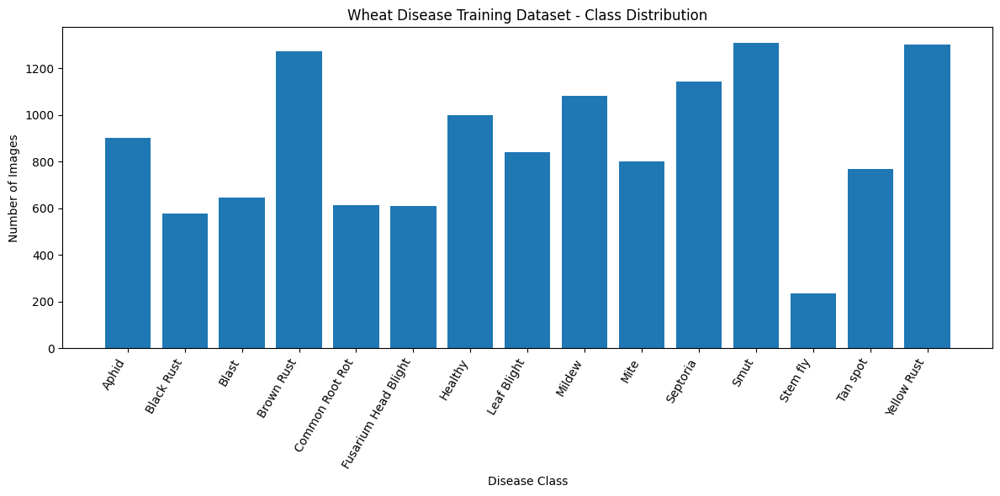

In [5]:

import os
import matplotlib.pyplot as plt


train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

image_extensions = (".png", ".jpg", ".jpeg")

class_names = []
class_counts = []

for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        count = sum(
            1 for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        )

        class_names.append(class_name)
        class_counts.append(count)


plt.figure(figsize=(12, 6))

plt.bar(class_names, class_counts)

plt.title("Wheat Disease Training Dataset - Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

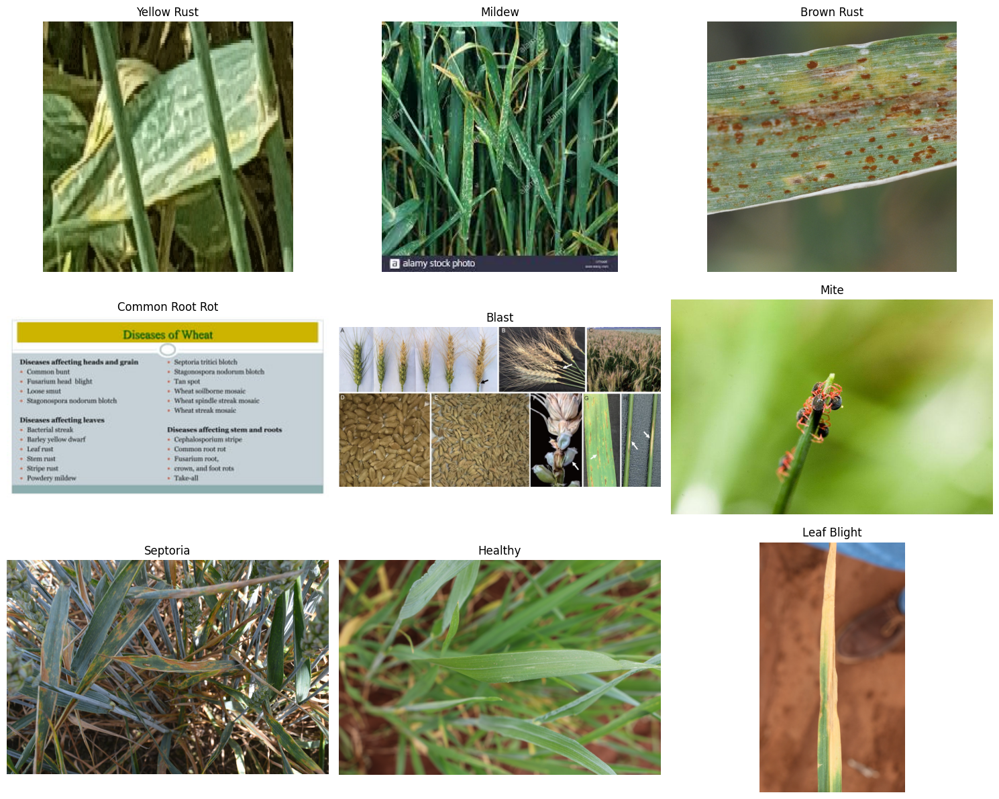

In [6]:

import os
import random
from PIL import Image
import matplotlib.pyplot as plt

train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"


classes = [
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
]


samples = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)

    image_files = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if image_files:
        file_name = random.choice(image_files)
        file_path = os.path.join(class_path, file_name)
        samples.append((class_name, file_path))


samples = samples[:9]

plt.figure(figsize=(15, 12))

for i, (class_name, file_path) in enumerate(samples):
    image = Image.open(file_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:

import os
from PIL import Image
from collections import Counter

train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

image_extensions = (".png", ".jpg", ".jpeg")


dimensions = []
total_images = 0
corrupted_images = []

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(image_extensions):

            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    dimensions.append(img.size)
                    total_images += 1

            except Exception as e:
                corrupted_images.append(file_path)

print("Total images checked:", total_images)
print("Corrupted images:", len(corrupted_images))


dimension_counts = Counter(dimensions)

print("\nMost common image dimensions:")

for dimension, count in dimension_counts.most_common(15):
    print(f"{dimension}: {count} images")

Total images checked: 13104
Corrupted images: 0

Most common image dimensions:
(256, 256): 2877 images
(709, 945): 503 images
(275, 183): 419 images
(709, 471): 339 images
(259, 194): 329 images
(6000, 4000): 285 images
(738, 491): 231 images
(567, 756): 203 images
(194, 259): 158 images
(225, 225): 114 images
(300, 168): 111 images
(183, 275): 107 images
(2848, 4272): 88 images
(299, 168): 74 images
(3264, 1836): 65 images


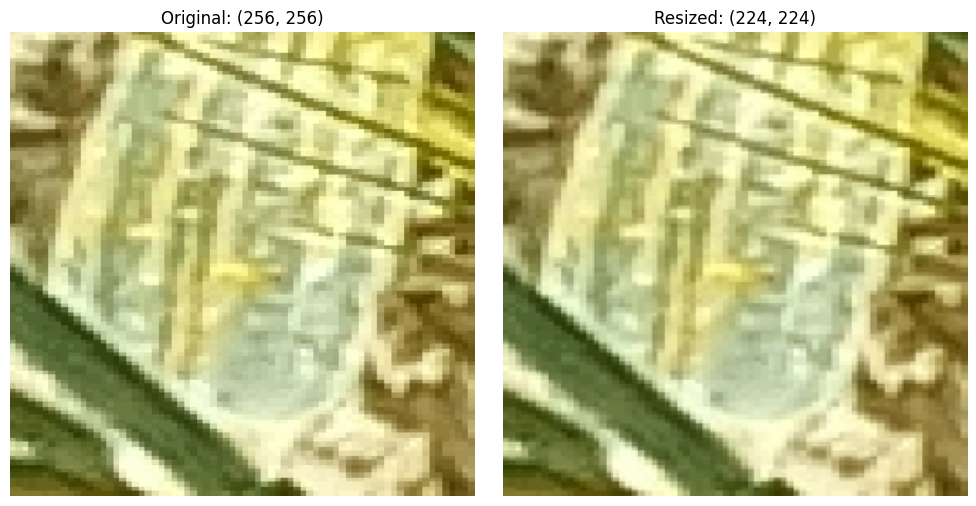

In [8]:

from PIL import Image
import matplotlib.pyplot as plt
import os


train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

class_name = "Yellow Rust"

class_path = os.path.join(train_path, class_name)

image_files = [
    file for file in os.listdir(class_path)
    if file.lower().endswith((".png", ".jpg", ".jpeg"))
]

image_path = os.path.join(class_path, image_files[0])


image = Image.open(image_path).convert("RGB")


resized_image = image.resize((224, 224))


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title(f"Resized: {resized_image.size}")
plt.axis("off")

plt.tight_layout()
plt.show()

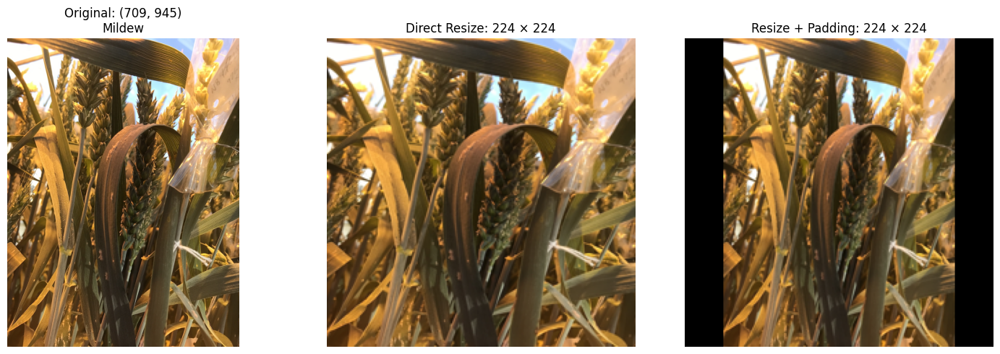

In [9]:

import os
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

train_path = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

image_extensions = (".png", ".jpg", ".jpeg")


selected_image = None
selected_class = None

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(image_extensions):

            file_path = os.path.join(class_path, file_name)

            with Image.open(file_path) as img:
                if img.width != img.height:
                    selected_image = file_path
                    selected_class = class_name
                    break

    if selected_image:
        break


image = Image.open(selected_image).convert("RGB")


direct_resize = image.resize((224, 224))


preserved_resize = ImageOps.contain(image, (224, 224))

canvas = Image.new("RGB", (224, 224), (0, 0, 0))

x = (224 - preserved_resize.width) // 2
y = (224 - preserved_resize.height) // 2

canvas.paste(preserved_resize, (x, y))


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}\n{selected_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(direct_resize)
plt.title("Direct Resize: 224 × 224")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canvas)
plt.title("Resize + Padding: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

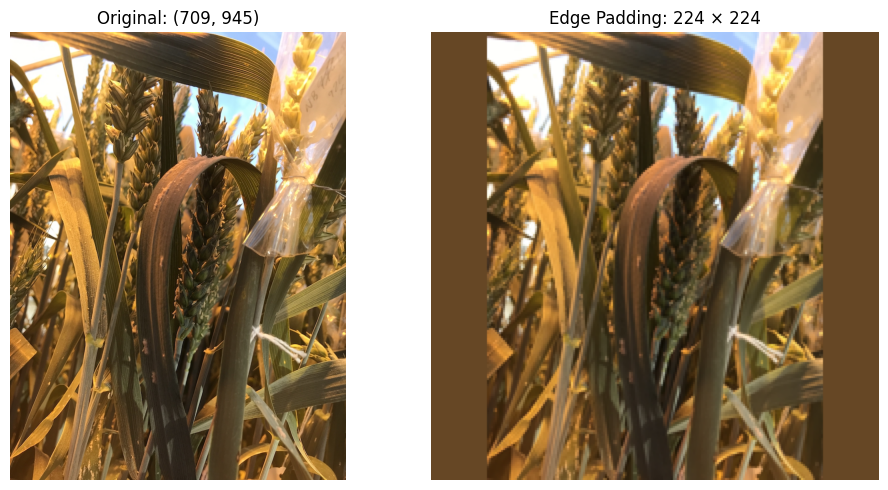

In [10]:

from PIL import Image, ImageOps
import matplotlib.pyplot as plt


image = Image.open(selected_image).convert("RGB")

target_size = (224, 224)


contained = ImageOps.contain(image, target_size)


edge_color = contained.getpixel((0, 0))

canvas = Image.new("RGB", target_size, edge_color)


x = (target_size[0] - contained.width) // 2
y = (target_size[1] - contained.height) // 2

canvas.paste(contained, (x, y))


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canvas)
plt.title("Edge Padding: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

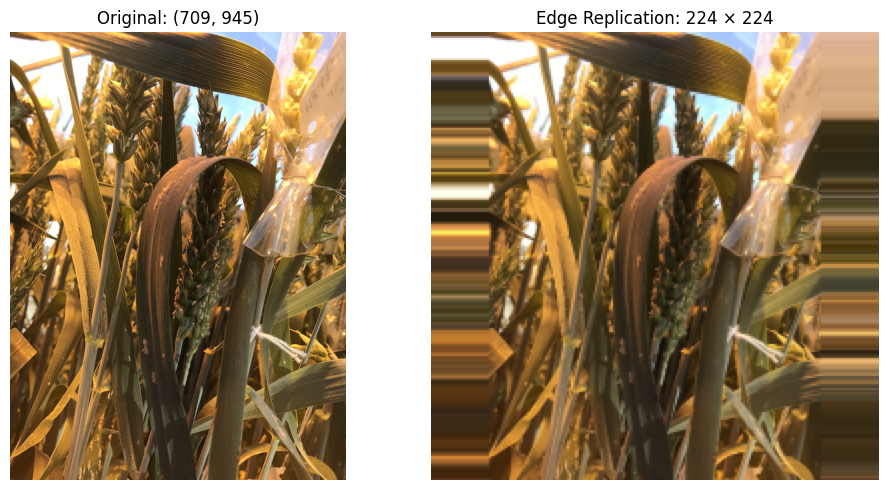

Final image shape: (224, 224, 3)


In [11]:

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt


image = Image.open(selected_image).convert("RGB")

target_size = 224


img_array = np.array(image)

h, w = img_array.shape[:2]


scale = target_size / max(h, w)

new_w = max(1, int(round(w * scale)))
new_h = max(1, int(round(h * scale)))

resized = cv2.resize(
    img_array,
    (new_w, new_h),
    interpolation=cv2.INTER_AREA
)


pad_h = target_size - new_h
pad_w = target_size - new_w

top = pad_h // 2
bottom = pad_h - top

left = pad_w // 2
right = pad_w - left


padded = cv2.copyMakeBorder(
    resized,
    top,
    bottom,
    left,
    right,
    borderType=cv2.BORDER_REPLICATE
)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded)
plt.title("Edge Replication: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Final image shape:", padded.shape)

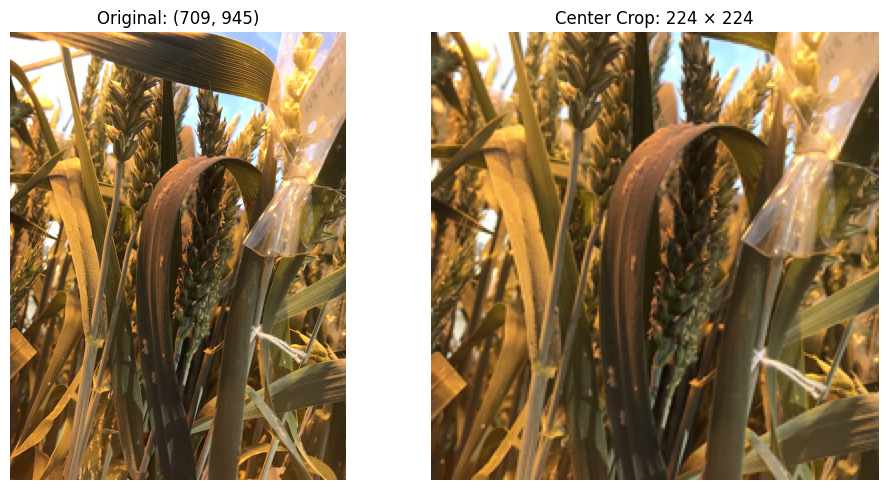

Final image size: (224, 224)


In [12]:

from PIL import Image, ImageOps
import matplotlib.pyplot as plt


image = Image.open(selected_image).convert("RGB")


center_crop = ImageOps.fit(
    image,
    (224, 224),
    method=Image.Resampling.LANCZOS,
    centering=(0.5, 0.5)
)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Original: {image.size}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(center_crop)
plt.title("Center Crop: 224 × 224")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Final image size:", center_crop.size)

In [13]:

import tensorflow as tf


DATASET_DIR = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Total classes:", len(class_names))

Found 13104 files belonging to 15 classes.
Using 10484 files for training.


I0000 00:00:1790855579.153811      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790855579.156660      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 13104 files belonging to 15 classes.
Using 2620 files for validation.
Classes: ['Aphid', 'Black Rust', 'Blast', 'Brown Rust', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Mite', 'Septoria', 'Smut', 'Stem fly', 'Tan spot', 'Yellow Rust']
Total classes: 15


In [14]:

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("\nAvailable GPUs:")
gpus = tf.config.list_physical_devices("GPU")
print(gpus)

if gpus:
    print("\nGPU available hai!")
else:
    print("\nGPU available nahi hai. CPU use hoga.")

TensorFlow version: 2.20.0

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

GPU available hai!


In [15]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("Available GPUs:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [16]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:")
print(tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [17]:
import tensorflow as tf
import os

DATASET_PATH = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nClasses:")
print(class_names)

print("\nNumber of classes:", num_classes)

Found 13104 files belonging to 15 classes.
Using 10484 files for training.
Found 13104 files belonging to 15 classes.
Using 2620 files for validation.

Classes:
['Aphid', 'Black Rust', 'Blast', 'Brown Rust', 'Common Root Rot', 'Fusarium Head Blight', 'Healthy', 'Leaf Blight', 'Mildew', 'Mite', 'Septoria', 'Smut', 'Stem fly', 'Tan spot', 'Yellow Rust']

Number of classes: 15


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


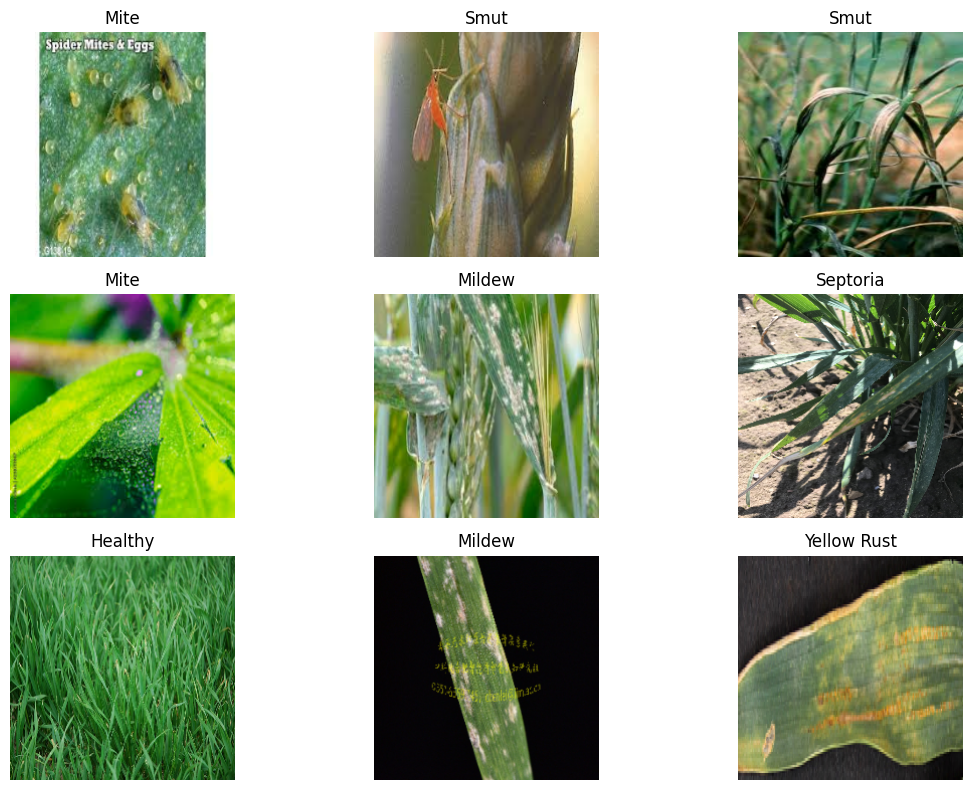

In [18]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    label_index = int(labels[i].numpy())
    plt.title(class_names[label_index])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

print("GPUs detected:", gpus)

strategy = tf.distribute.MirroredStrategy()

print("Number of GPUs being used:", strategy.num_replicas_in_sync)

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs being used: 2


In [20]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

with strategy.scope():

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="data_augmentation")

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        data_augmentation,

        layers.Rescaling(1./127.5, offset=-1),

        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.3),

        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,199 (8.69 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [22]:
TEST_PATH = os.path.join(DATASET_PATH, "test")

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

print("Test classes:")
print(test_ds.class_names)

print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 750 files belonging to 15 classes.
Test classes:
['aphid_test', 'black_rust_test', 'blast_test', 'brown_rust_test', 'common_root_rot_test', 'fusarium_head_blight_test', 'healthy_test', 'leaf_blight_test', 'mildew_test', 'mite_test', 'septoria_test', 'smut_test', 'stem_fly_test', 'tan_spot_test', 'yellow_rust_test']
Test batches: 24


In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.6387 - loss: 1.3917
Test Loss: 1.3916590213775635
Test Accuracy: 0.6386666893959045
Test Accuracy (%): 63.866668939590454


24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step


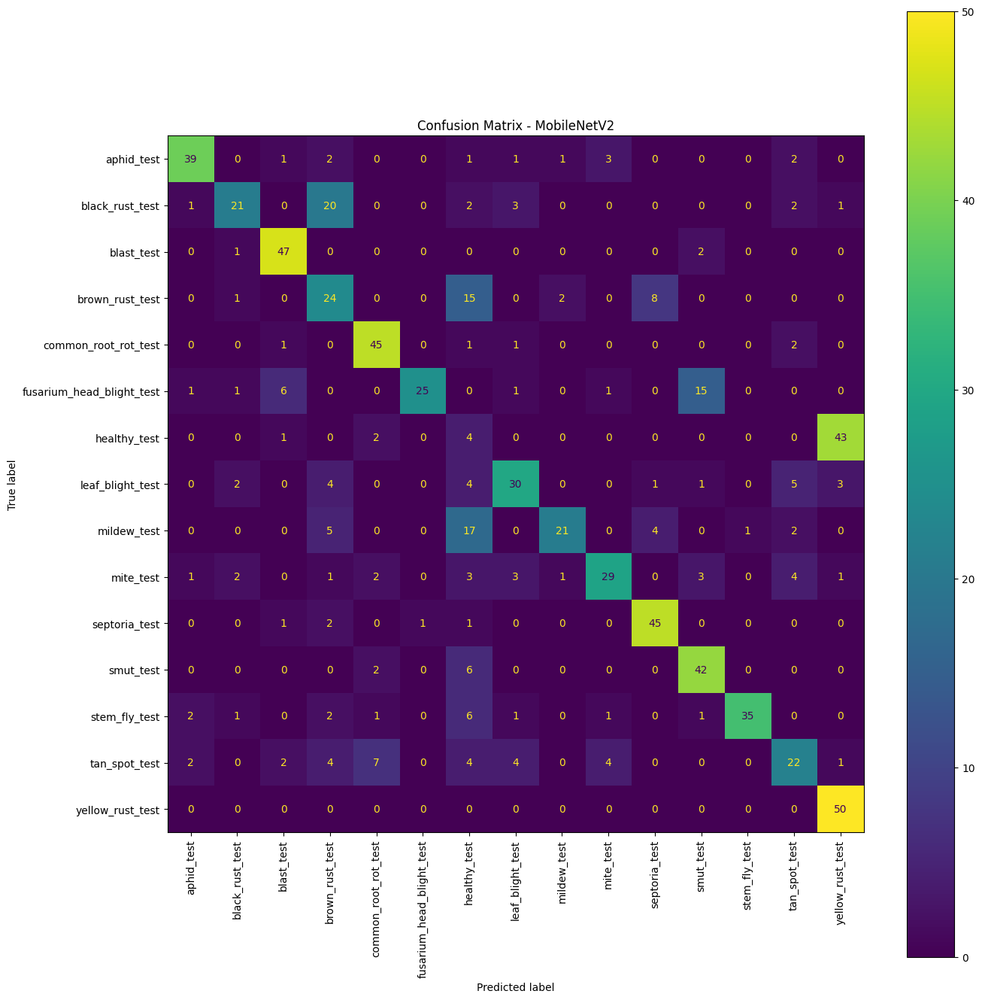

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = np.concatenate([y.numpy() for _, y in test_ds])

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 14))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_ds.class_names
)
disp.plot(
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca()
)

plt.title("Confusion Matrix - MobileNetV2")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=test_ds.class_names,
    digits=4
)

print(report)

                           precision    recall  f1-score   support

               aphid_test     0.8478    0.7800    0.8125        50
          black_rust_test     0.7241    0.4200    0.5316        50
               blast_test     0.7966    0.9400    0.8624        50
          brown_rust_test     0.3750    0.4800    0.4211        50
     common_root_rot_test     0.7627    0.9000    0.8257        50
fusarium_head_blight_test     0.9615    0.5000    0.6579        50
             healthy_test     0.0625    0.0800    0.0702        50
         leaf_blight_test     0.6818    0.6000    0.6383        50
              mildew_test     0.8400    0.4200    0.5600        50
                mite_test     0.7632    0.5800    0.6591        50
            septoria_test     0.7759    0.9000    0.8333        50
                smut_test     0.6562    0.8400    0.7368        50
            stem_fly_test     0.9722    0.7000    0.8140        50
            tan_spot_test     0.5641    0.4400    0.4944     

In [26]:
model.save("/kaggle/working/mobilenetv2_baseline.keras")

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [27]:

base_model.trainable = True


for layer in base_model.layers[:-30]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 30


In [28]:
with strategy.scope():

    base_model.trainable = True

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Total layers: 154
Trainable layers: 30


In [29]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
INFO:tensorflow:Collective all_reduce tensors: 34 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
328/328 ━━━━━━━━━━━━━━━━━━━━ 82s 216ms/step - accuracy: 0.5922 - loss: 1.3396 - val_accuracy: 0.7324 - val_loss: 0.8620
Epoch 2/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 210ms/step - accuracy: 0.6600 - loss: 1.0482 - val_accuracy: 0.7420 - val_loss: 0.8430
Epoch 3/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 209ms/step - accuracy: 0.6890 - loss: 0.9526 - val_accuracy: 0.7389 - val_loss: 0.8276
Epoch 4/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 70s 212ms/step - accuracy: 0.7034 - loss: 0.9100 - val_accuracy: 0.7393 - val_loss: 0.8133
Epoch 5/5
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 211ms/step - accuracy: 0.7181 - loss: 0.8513 - val_accuracy: 0.7443 - val_loss: 0.7907


In [30]:
fine_tune_test_loss, fine_tune_test_accuracy = model.evaluate(test_ds)

print("Fine-tuned Test Loss:", fine_tune_test_loss)
print("Fine-tuned Test Accuracy:", fine_tune_test_accuracy)
print("Fine-tuned Test Accuracy (%):", fine_tune_test_accuracy * 100)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.7093 - loss: 1.2252
Fine-tuned Test Loss: 1.2251636981964111
Fine-tuned Test Accuracy: 0.7093333601951599
Fine-tuned Test Accuracy (%): 70.93333601951599


24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step


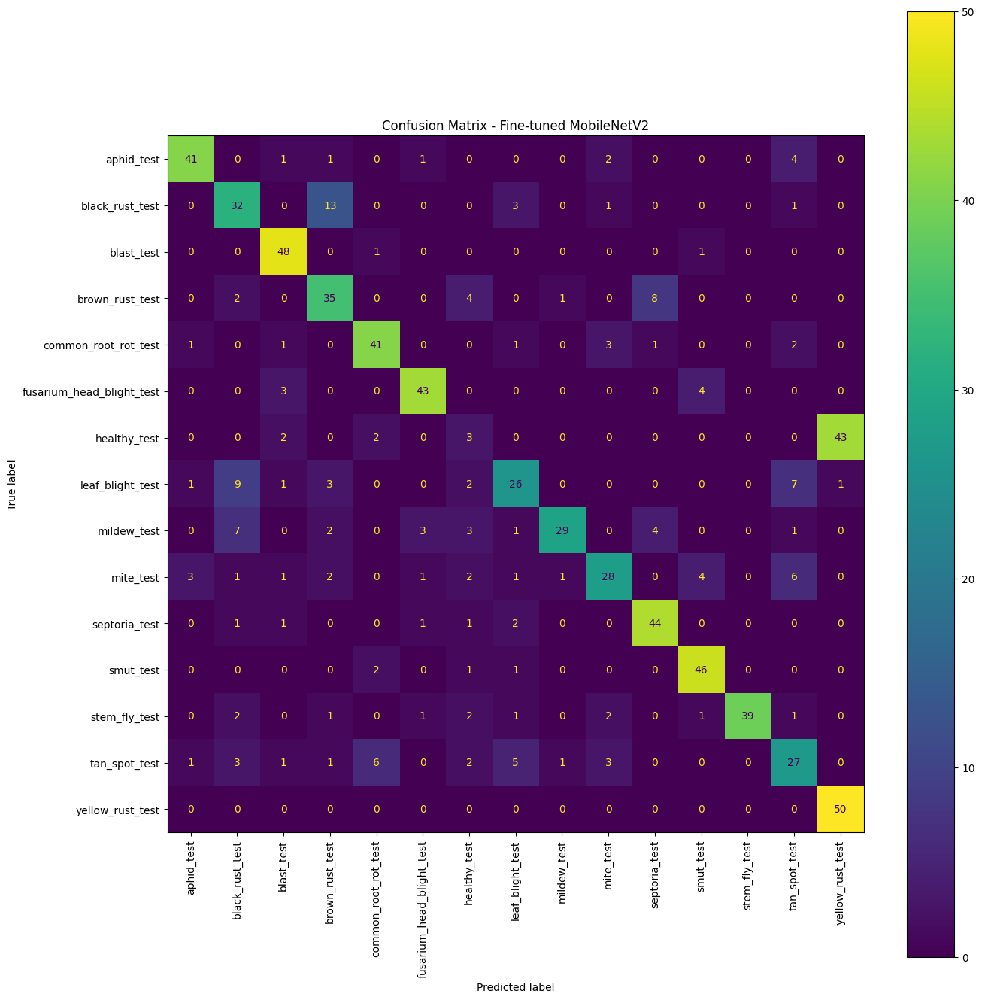

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predictions from fine-tuned model
fine_tune_pred_probs = model.predict(test_ds)
fine_tune_y_pred = np.argmax(fine_tune_pred_probs, axis=1)

# Confusion matrix
fine_tune_cm = confusion_matrix(y_true, fine_tune_y_pred)

plt.figure(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=fine_tune_cm,
    display_labels=test_ds.class_names
)

disp.plot(
    xticks_rotation=90,
    values_format="d",
    ax=plt.gca()
)

plt.title("Confusion Matrix - Fine-tuned MobileNetV2")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report

fine_tune_report = classification_report(
    y_true,
    fine_tune_y_pred,
    target_names=test_ds.class_names,
    digits=4
)

print(fine_tune_report)

                           precision    recall  f1-score   support

               aphid_test     0.8723    0.8200    0.8454        50
          black_rust_test     0.5614    0.6400    0.5981        50
               blast_test     0.8136    0.9600    0.8807        50
          brown_rust_test     0.6034    0.7000    0.6481        50
     common_root_rot_test     0.7885    0.8200    0.8039        50
fusarium_head_blight_test     0.8600    0.8600    0.8600        50
             healthy_test     0.1500    0.0600    0.0857        50
         leaf_blight_test     0.6341    0.5200    0.5714        50
              mildew_test     0.9062    0.5800    0.7073        50
                mite_test     0.7179    0.5600    0.6292        50
            septoria_test     0.7719    0.8800    0.8224        50
                smut_test     0.8214    0.9200    0.8679        50
            stem_fly_test     1.0000    0.7800    0.8764        50
            tan_spot_test     0.5510    0.5400    0.5455     

Total Healthy test images: 50


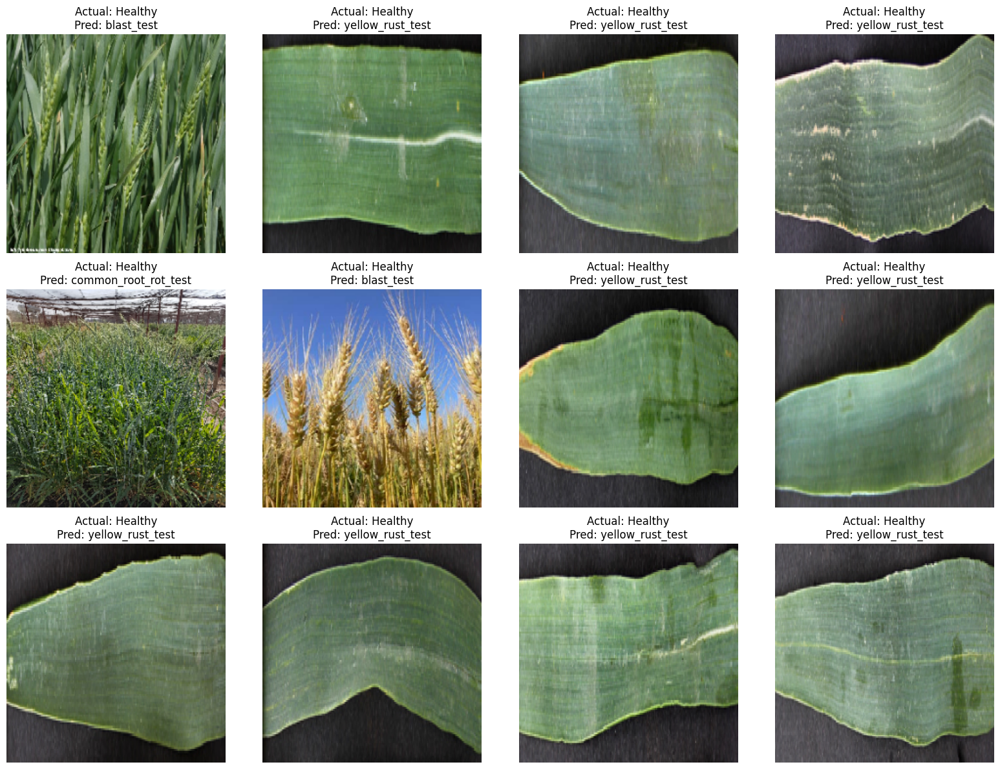

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Load all test images in the same order as test_ds
test_images = np.concatenate(
    [images.numpy() for images, _ in test_ds],
    axis=0
)

test_labels = np.concatenate(
    [labels.numpy() for _, labels in test_ds],
    axis=0
)

healthy_class = test_ds.class_names.index("healthy_test")

healthy_indices = np.where(test_labels == healthy_class)[0]

print("Total Healthy test images:", len(healthy_indices))

plt.figure(figsize=(16, 12))

for i, idx in enumerate(healthy_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(test_images[idx].astype("uint8"))

    predicted_class = test_ds.class_names[fine_tune_y_pred[idx]]

    plt.title(
        f"Actual: Healthy\nPred: {predicted_class}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
import os
from PIL import Image

corrupted_test = []

for class_name in os.listdir(TEST_PATH):
    class_path = os.path.join(TEST_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            corrupted_test.append(file_path)

print("Total corrupted test images:", len(corrupted_test))

if corrupted_test:
    print("\nCorrupted files:")
    for path in corrupted_test[:20]:
        print(path)

Total corrupted test images: 0


In [35]:
import os
import hashlib
from collections import defaultdict

def get_image_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

all_images = []

for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        if os.path.isfile(file_path):
            all_images.append((file_path, class_name))

hash_map = defaultdict(list)

for file_path, class_name in all_images:
    try:
        image_hash = get_image_hash(file_path)
        hash_map[image_hash].append((file_path, class_name))
    except Exception:
        pass

duplicate_groups = [
    items for items in hash_map.values()
    if len(items) > 1
]

duplicate_images = sum(len(group) for group in duplicate_groups)

print("Total images checked:", len(all_images))
print("Duplicate groups:", len(duplicate_groups))
print("Images involved in duplicates:", duplicate_images)

if duplicate_groups:
    print("\nFirst few duplicate groups:")
    for group in duplicate_groups[:10]:
        print("\n---")
        for path, class_name in group:
            print(class_name, "->", path)

Total images checked: 0
Duplicate groups: 0
Images involved in duplicates: 0


In [36]:
import os
import hashlib
from collections import defaultdict

def get_image_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

image_files = []

# Check both train and test
for split_name, split_path in [
    ("train", TRAIN_PATH),
    ("test", TEST_PATH)
]:
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            if os.path.isfile(file_path):
                image_files.append(
                    (file_path, split_name, class_name)
                )

hash_map = defaultdict(list)

for file_path, split_name, class_name in image_files:
    try:
        image_hash = get_image_hash(file_path)
        hash_map[image_hash].append(
            (file_path, split_name, class_name)
        )
    except Exception:
        pass

duplicate_groups = [
    items for items in hash_map.values()
    if len(items) > 1
]

duplicate_images = sum(
    len(group) for group in duplicate_groups
)

print("Total images checked:", len(image_files))
print("Duplicate groups:", len(duplicate_groups))
print("Images involved in duplicates:", duplicate_images)

if duplicate_groups:
    print("\nFirst 10 duplicate groups:")

    for group in duplicate_groups[:10]:
        print("\n---")
        for path, split_name, class_name in group:
            print(
                split_name,
                "|",
                class_name,
                "|",
                path
            )

Total images checked: 13854
Duplicate groups: 1743
Images involved in duplicates: 4454

First 10 duplicate groups:

---
train | Brown Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Brown Rust/brown_rust_1128.png
train | Black Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Black Rust/black_rust_93.png

---
train | Brown Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Brown Rust/brown_rust_1070.png
train | Black Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Black Rust/black_rust_61.png

---
train | Brown Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Brown Rust/brown_rust_1136.png
train | Black Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Black Rust/black_rust_97.png

---
train | Brown Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Brown Rust/brown_rust_1094.png
train | Black Rust | /kaggle/in

In [37]:
same_class_groups = 0
cross_class_groups = 0
train_test_groups = 0

same_class_images = 0
cross_class_images = 0
train_test_images = 0

for group in duplicate_groups:

    classes = set(item[2] for item in group)
    splits = set(item[1] for item in group)

    # Duplicate within the same class
    if len(classes) == 1:
        same_class_groups += 1
        same_class_images += len(group)

    # Exact same image assigned to different classes
    if len(classes) > 1:
        cross_class_groups += 1
        cross_class_images += len(group)

    # Exact duplicate appears in both train and test
    if "train" in splits and "test" in splits:
        train_test_groups += 1
        train_test_images += len(group)

print("========== DUPLICATE AUDIT ==========")

print("Same-class duplicate groups:", same_class_groups)
print("Images in same-class duplicates:", same_class_images)

print("\nCross-class duplicate groups:", cross_class_groups)
print("Images in cross-class duplicates:", cross_class_images)

print("\nTrain-Test duplicate groups:", train_test_groups)
print("Images involved in train-test duplicates:", train_test_images)

========== DUPLICATE AUDIT ==========
Same-class duplicate groups: 1021
Images in same-class duplicates: 2701

Cross-class duplicate groups: 722
Images in cross-class duplicates: 1753

Train-Test duplicate groups: 486
Images involved in train-test duplicates: 1240


In [38]:
from collections import Counter

same_label_train_test = 0
cross_label_train_test = 0

same_label_image_occurrences = 0
cross_label_image_occurrences = 0

cross_label_examples = []

for group in duplicate_groups:

    splits = set(item[1] for item in group)

    if "train" not in splits or "test" not in splits:
        continue

    train_items = [item for item in group if item[1] == "train"]
    test_items = [item for item in group if item[1] == "test"]

    train_classes = set(item[2] for item in train_items)
    test_classes = set(item[2] for item in test_items)

    if train_classes == test_classes and len(train_classes) == 1:
        same_label_train_test += 1
        same_label_image_occurrences += len(train_items) + len(test_items)

    else:
        cross_label_train_test += 1
        cross_label_image_occurrences += len(train_items) + len(test_items)

        if len(cross_label_examples) < 10:
            cross_label_examples.append((train_items, test_items))

print("========== TRAIN-TEST DUPLICATE BREAKDOWN ==========")

print("Same-label train-test groups:", same_label_train_test)
print("Same-label image occurrences:", same_label_image_occurrences)

print("\nCross-label train-test groups:", cross_label_train_test)
print("Cross-label image occurrences:", cross_label_image_occurrences)

print("\nFirst cross-label examples:")

for i, (train_items, test_items) in enumerate(cross_label_examples, 1):

    print(f"\n--- Example {i} ---")

    print("TRAIN:")
    for path, split, class_name in train_items:
        print(class_name, "|", path)

    print("TEST:")
    for path, split, class_name in test_items:
        print(class_name, "|", path)

========== TRAIN-TEST DUPLICATE BREAKDOWN ==========
Same-label train-test groups: 0
Same-label image occurrences: 0

Cross-label train-test groups: 486
Cross-label image occurrences: 1240

First cross-label examples:

--- Example 1 ---
TRAIN:
Brown Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Brown Rust/brown_rust_1031.png
Black Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Black Rust/black_rust_43.png
TEST:
black_rust_test | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/test/black_rust_test/black_rust_43.png

--- Example 2 ---
TRAIN:
Brown Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Brown Rust/brown_rust_1038.png
Black Rust | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/train/Black Rust/black_rust_48.png
TEST:
black_rust_test | /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/test/black_rust_test/black_rust_48.png

--- Example 3 ---
TRAIN:
Brown Rust

In [39]:
from collections import defaultdict, Counter

# Map each hash to all its occurrences
hash_groups = defaultdict(list)

for file_path, split_name, class_name in image_files:
    try:
        image_hash = get_image_hash(file_path)
        hash_groups[image_hash].append(
            (file_path, split_name, class_name)
        )
    except Exception:
        pass

contaminated_test_files = set()
test_conflict_pairs = Counter()

for group in hash_groups.values():

    train_items = [x for x in group if x[1] == "train"]
    test_items = [x for x in group if x[1] == "test"]

    if not train_items or not test_items:
        continue

    train_classes = set(x[2] for x in train_items)

    # Test images whose label conflicts with at least one train label
    for test_path, _, test_class in test_items:

        conflicting_classes = train_classes - {test_class}

        if conflicting_classes:
            contaminated_test_files.add(test_path)

            for train_class in conflicting_classes:
                test_conflict_pairs[(test_class, train_class)] += 1

print("========== UNIQUE TEST CONTAMINATION ==========")

print(
    "Unique test images with cross-label train duplicates:",
    len(contaminated_test_files)
)

print("\nTop test-label → conflicting-train-label pairs:")

for (test_class, train_class), count in test_conflict_pairs.most_common(20):
    print(
        f"{test_class}  <--conflict-->  {train_class}: {count}"
    )

========== UNIQUE TEST CONTAMINATION ==========
Unique test images with cross-label train duplicates: 495

Top test-label → conflicting-train-label pairs:
black_rust_test  <--conflict-->  Black Rust: 50
common_root_rot_test  <--conflict-->  Common Root Rot: 50
blast_test  <--conflict-->  Blast: 50
mite_test  <--conflict-->  Mite: 50
septoria_test  <--conflict-->  Septoria: 50
tan_spot_test  <--conflict-->  Tan spot: 50
leaf_blight_test  <--conflict-->  Leaf Blight: 50
stem_fly_test  <--conflict-->  Stem fly: 50
aphid_test  <--conflict-->  Aphid: 50
smut_test  <--conflict-->  Smut: 43
black_rust_test  <--conflict-->  Brown Rust: 11
septoria_test  <--conflict-->  Leaf Blight: 4
tan_spot_test  <--conflict-->  Leaf Blight: 2
fusarium_head_blight_test  <--conflict-->  Fusarium Head Blight: 2
mite_test  <--conflict-->  Leaf Blight: 1
leaf_blight_test  <--conflict-->  Tan spot: 1
leaf_blight_test  <--conflict-->  Aphid: 1


In [40]:
# Normalize train/test class names so that
# "Black Rust" and "black_rust_test" are treated as the same class.

def normalize_class_name(class_name):
    name = class_name.lower().strip()
    
    # Remove "_test" from test class names
    name = name.replace("_test", "")
    
    # Convert underscores to spaces
    name = name.replace("_", " ")
    
    return name


corrected_contaminated_test_files = set()
corrected_conflict_pairs = Counter()

for group in hash_groups.values():

    train_items = [x for x in group if x[1] == "train"]
    test_items = [x for x in group if x[1] == "test"]

    if not train_items or not test_items:
        continue

    train_classes = set(
        normalize_class_name(x[2])
        for x in train_items
    )

    test_classes = set(
        normalize_class_name(x[2])
        for x in test_items
    )

    # Actual label conflict:
    # test label does NOT match any train label
    for test_path, _, test_class_raw in test_items:

        test_class = normalize_class_name(test_class_raw)

        conflicting_classes = train_classes - {test_class}

        if conflicting_classes:

            corrected_contaminated_test_files.add(test_path)

            for train_class in conflicting_classes:
                corrected_conflict_pairs[
                    (test_class, train_class)
                ] += 1


print("========== CORRECTED TEST CONTAMINATION AUDIT ==========")

print(
    "Unique test images with ACTUAL cross-label train duplicates:",
    len(corrected_contaminated_test_files)
)

print("\nActual cross-label conflict pairs:")

if corrected_conflict_pairs:

    for (test_class, train_class), count in corrected_conflict_pairs.most_common(20):
        print(
            f"{test_class}  <--conflict-->  {train_class}: {count}"
        )

else:
    print("No cross-label train-test conflicts found.")

========== CORRECTED TEST CONTAMINATION AUDIT ==========
Unique test images with ACTUAL cross-label train duplicates: 20

Actual cross-label conflict pairs:
black rust  <--conflict-->  brown rust: 11
septoria  <--conflict-->  leaf blight: 4
tan spot  <--conflict-->  leaf blight: 2
mite  <--conflict-->  leaf blight: 1
leaf blight  <--conflict-->  tan spot: 1
leaf blight  <--conflict-->  aphid: 1


Unique conflicting test images: 20


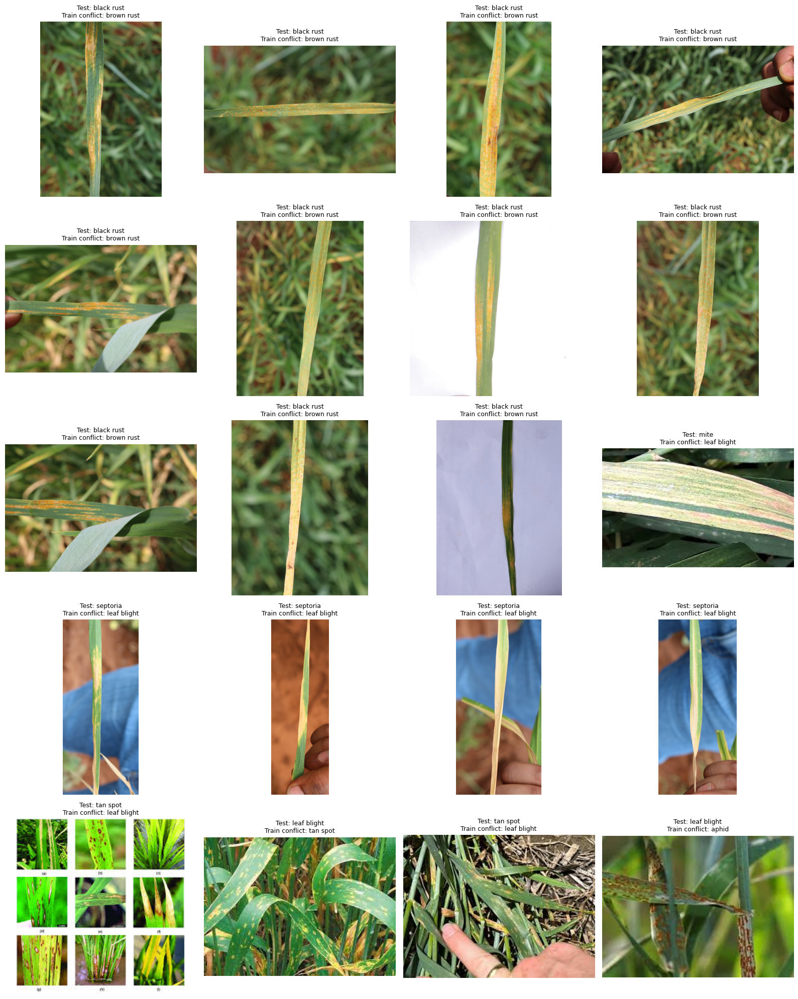

In [41]:
from PIL import Image
import matplotlib.pyplot as plt
import os

conflict_records = []

for group in hash_groups.values():

    train_items = [x for x in group if x[1] == "train"]
    test_items = [x for x in group if x[1] == "test"]

    if not train_items or not test_items:
        continue

    train_classes = set(
        normalize_class_name(x[2])
        for x in train_items
    )

    for test_path, _, test_class_raw in test_items:

        test_class = normalize_class_name(test_class_raw)

        conflicting_classes = train_classes - {test_class}

        if conflicting_classes:

            conflict_records.append({
                "test_path": test_path,
                "test_class": test_class,
                "train_conflicts": sorted(conflicting_classes)
            })

# Remove accidental duplicates of the same test image
unique_records = {}
for record in conflict_records:
    unique_records[record["test_path"]] = record

conflict_records = list(unique_records.values())

print("Unique conflicting test images:", len(conflict_records))

# Display all conflicting test images
plt.figure(figsize=(16, 20))

for i, record in enumerate(conflict_records):

    img = Image.open(record["test_path"]).convert("RGB")

    plt.subplot(5, 4, i + 1)
    plt.imshow(img)

    conflict_text = ", ".join(record["train_conflicts"])

    plt.title(
        f"Test: {record['test_class']}\n"
        f"Train conflict: {conflict_text}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
# Analyze exact duplicate images that appear
# under different classes inside the TRAIN set.

train_cross_class_groups = 0
train_cross_class_files = set()
train_conflict_pairs = Counter()

for group in hash_groups.values():

    train_items = [
        x for x in group
        if x[1] == "train"
    ]

    if len(train_items) < 2:
        continue

    # Normalize class names
    train_classes = set(
        normalize_class_name(x[2])
        for x in train_items
    )

    # Only genuine cross-class duplicates
    if len(train_classes) > 1:

        train_cross_class_groups += 1

        for path, split, class_name in train_items:
            train_cross_class_files.add(path)

        classes = sorted(train_classes)

        # Record class-pair conflicts
        for i in range(len(classes)):
            for j in range(i + 1, len(classes)):
                train_conflict_pairs[
                    (classes[i], classes[j])
                ] += 1


print("========== TRAINING CROSS-CLASS DUPLICATE AUDIT ==========")

print(
    "Cross-class duplicate groups:",
    train_cross_class_groups
)

print(
    "Unique training images involved:",
    len(train_cross_class_files)
)

print("\nTop conflicting class pairs:")

for (class1, class2), count in train_conflict_pairs.most_common(20):
    print(
        f"{class1}  <-->  {class2}: {count}"
    )

========== TRAINING CROSS-CLASS DUPLICATE AUDIT ==========
Cross-class duplicate groups: 256
Unique training images involved: 559

Top conflicting class pairs:
black rust  <-->  brown rust: 102
leaf blight  <-->  septoria: 97
leaf blight  <-->  tan spot: 25
aphid  <-->  leaf blight: 6
leaf blight  <-->  smut: 4
brown rust  <-->  tan spot: 3
blast  <-->  leaf blight: 3
leaf blight  <-->  mite: 3
smut  <-->  tan spot: 3
brown rust  <-->  leaf blight: 2
common root rot  <-->  leaf blight: 2
common root rot  <-->  tan spot: 2
blast  <-->  tan spot: 2
aphid  <-->  tan spot: 2
aphid  <-->  brown rust: 1
aphid  <-->  common root rot: 1
common root rot  <-->  smut: 1
blast  <-->  common root rot: 1
blast  <-->  healthy: 1
black rust  <-->  leaf blight: 1


In [43]:
# Final normalized train-test exact duplicate audit

same_label_leak_groups = 0
same_label_leak_test_files = set()

for group in hash_groups.values():

    train_items = [x for x in group if x[1] == "train"]
    test_items = [x for x in group if x[1] == "test"]

    if not train_items or not test_items:
        continue

    train_classes = {
        normalize_class_name(x[2])
        for x in train_items
    }

    test_classes = {
        normalize_class_name(x[2])
        for x in test_items
    }

    # Exact duplicate exists across train/test
    # and labels are actually the SAME
    if train_classes & test_classes:

        same_label_leak_groups += 1

        for path, _, test_class in test_items:
            if normalize_class_name(test_class) in train_classes:
                same_label_leak_test_files.add(path)

print("========== FINAL TRAIN-TEST LEAKAGE AUDIT ==========")

print(
    "Same-label train-test duplicate groups:",
    same_label_leak_groups
)

print(
    "Unique test images involved:",
    len(same_label_leak_test_files)
)


========== FINAL TRAIN-TEST LEAKAGE AUDIT ==========
Same-label train-test duplicate groups: 486
Unique test images involved: 495


In [44]:
from collections import Counter

clean_test_files = []

for file_path, split_name, class_name in image_files:

    if split_name != "test":
        continue

    # Exclude exact train-test leakage
    if file_path not in same_label_leak_test_files:
        clean_test_files.append(
            (file_path, normalize_class_name(class_name))
        )

clean_test_counts = Counter(
    class_name for _, class_name in clean_test_files
)

print("========== CLEAN TEST SET ==========")

print("Original test images:", 750)
print("Leaked test images:", len(same_label_leak_test_files))
print("Remaining clean test images:", len(clean_test_files))

print("\nClass-wise clean test counts:")

for class_name, count in sorted(clean_test_counts.items()):
    print(f"{class_name:25s}: {count}")

========== CLEAN TEST SET ==========
Original test images: 750
Leaked test images: 495
Remaining clean test images: 255

Class-wise clean test counts:
brown rust               : 50
fusarium head blight     : 48
healthy                  : 50
mildew                   : 50
smut                     : 7
yellow rust              : 50


In [45]:
# Create a clean training pool by excluding
# exact duplicate images that have conflicting class labels.

clean_training_records = []

excluded_conflict_files = set()

for group in hash_groups.values():

    train_items = [
        x for x in group
        if x[1] == "train"
    ]

    if not train_items:
        continue

    train_classes = {
        normalize_class_name(x[2])
        for x in train_items
    }

    # If the exact same image exists under multiple
    # different labels, exclude ALL copies from
    # the clean training pool.
    if len(train_classes) > 1:

        for path, split, class_name in train_items:
            excluded_conflict_files.add(path)

# Build clean training records
for file_path, split_name, class_name in image_files:

    if split_name != "train":
        continue

    if file_path in excluded_conflict_files:
        continue

    clean_training_records.append(
        (
            file_path,
            normalize_class_name(class_name)
        )
    )

print("========== CLEAN TRAINING POOL ==========")

print("Original training images:", 13104)

print(
    "Excluded conflicting images:",
    len(excluded_conflict_files)
)

print(
    "Remaining clean training images:",
    len(clean_training_records)
)

print("\nClass-wise clean training counts:")

clean_train_counts = Counter(
    class_name
    for _, class_name in clean_training_records
)

for class_name, count in sorted(clean_train_counts.items()):
    print(f"{class_name:25s}: {count}")

========== CLEAN TRAINING POOL ==========
Original training images: 13104
Excluded conflicting images: 559
Remaining clean training images: 12545

Class-wise clean training counts:
aphid                    : 894
black rust               : 459
blast                    : 640
brown rust               : 1163
common root rot          : 607
fusarium head blight     : 611
healthy                  : 999
leaf blight              : 694
mildew                   : 1081
mite                     : 797
septoria                 : 1047
smut                     : 1286
stem fly                 : 234
tan spot                 : 732
yellow rust              : 1301


In [46]:
# Remove exact duplicate copies from the conflict-free training pool.
# We keep only ONE representative image for each exact image hash.

clean_unique_training = []
seen_hashes = set()

for file_path, class_name in clean_training_records:

    try:
        image_hash = get_image_hash(file_path)

        if image_hash not in seen_hashes:
            seen_hashes.add(image_hash)

            clean_unique_training.append(
                (file_path, class_name)
            )

    except Exception:
        pass

print("========== UNIQUE CLEAN TRAINING DATA ==========")

print("Conflict-free training images:", len(clean_training_records))
print("Unique clean images:", len(clean_unique_training))
print(
    "Exact duplicate copies removed:",
    len(clean_training_records) - len(clean_unique_training)
)

print("\nClass-wise unique clean counts:")

unique_clean_counts = Counter(
    class_name
    for _, class_name in clean_unique_training
)

for class_name, count in sorted(unique_clean_counts.items()):
    print(f"{class_name:25s}: {count}")

========== UNIQUE CLEAN TRAINING DATA ==========
Conflict-free training images: 12545
Unique clean images: 10632
Exact duplicate copies removed: 1913

Class-wise unique clean counts:
aphid                    : 870
black rust               : 330
blast                    : 587
brown rust               : 1162
common root rot          : 580
fusarium head blight     : 597
healthy                  : 986
leaf blight              : 616
mildew                   : 1081
mite                     : 771
septoria                 : 349
smut                     : 518
stem fly                 : 172
tan spot                 : 712
yellow rust              : 1301


In [47]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Create dataframe
clean_df = pd.DataFrame(
    clean_unique_training,
    columns=["filepath", "class_name"]
)

print("Total unique clean images:", len(clean_df))

# -------------------------------
# 1. 80% Train + 20% Temporary
# -------------------------------

train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.20,
    random_state=42,
    stratify=clean_df["class_name"]
)

# -------------------------------
# 2. Split temporary into
#    10% Validation + 10% Test
# -------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["class_name"]
)

print("\n========== CLEAN DATA SPLIT ==========")

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nExpected ratio:")
print("Train      ≈ 80%")
print("Validation ≈ 10%")
print("Test       ≈ 10%")

print("\n========== CLASS DISTRIBUTION ==========")

distribution = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": val_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
}).fillna(0).astype(int)

print(distribution.sort_index())

Total unique clean images: 10632

========== CLEAN DATA SPLIT ==========
Train images: 8505
Validation images: 1063
Test images: 1064

Expected ratio:
Train      ≈ 80%
Validation ≈ 10%
Test       ≈ 10%

========== CLASS DISTRIBUTION ==========
                      Train  Validation  Test
class_name                                   
aphid                   696          87    87
black rust              264          33    33
blast                   470          59    58
brown rust              929         116   117
common root rot         464          58    58
fusarium head blight    477          60    60
healthy                 789          98    99
leaf blight             493          62    61
mildew                  865         108   108
mite                    617          77    77
septoria                279          35    35
smut                    414          52    52
stem fly                138          17    17
tan spot                569          71    72
yellow rust         

In [48]:
import tensorflow as tf
import numpy as np
from collections import Counter

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Consistent class order
class_names_clean = sorted(clean_df["class_name"].unique())

class_to_index = {
    class_name: i
    for i, class_name in enumerate(class_names_clean)
}

print("Classes:", class_names_clean)
print("Number of classes:", len(class_names_clean))


# ------------------------------------------------
# Function to load one image
# ------------------------------------------------

def load_image(file_path, label):

    image = tf.io.read_file(file_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(image, tf.float32)

    return image, label


# ------------------------------------------------
# Convert dataframe → tf.data.Dataset
# ------------------------------------------------

def create_clean_dataset(df, shuffle=False):

    paths = df["filepath"].values

    labels = np.array([
        class_to_index[class_name]
        for class_name in df["class_name"]
    ])

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


# ------------------------------------------------
# Create clean datasets
# ------------------------------------------------

clean_train_ds = create_clean_dataset(
    train_df,
    shuffle=True
)

clean_val_ds = create_clean_dataset(
    val_df,
    shuffle=False
)

clean_test_ds = create_clean_dataset(
    test_df,
    shuffle=False
)


# ------------------------------------------------
# Class weights
# ------------------------------------------------

train_counts = Counter(train_df["class_name"])

total_train = len(train_df)
num_classes = len(class_names_clean)

class_weights = {}

for class_name, class_index in class_to_index.items():

    class_weights[class_index] = (
        total_train /
        (num_classes * train_counts[class_name])
    )


print("\n========== CLEAN DATASETS ==========")

print("Train batches:", tf.data.experimental.cardinality(clean_train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(clean_val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(clean_test_ds).numpy())

print("\n========== CLASS WEIGHTS ==========")

for class_name, class_index in class_to_index.items():
    print(
        f"{class_name:25s}: "
        f"{class_weights[class_index]:.3f}"
    )

Classes: ['aphid', 'black rust', 'blast', 'brown rust', 'common root rot', 'fusarium head blight', 'healthy', 'leaf blight', 'mildew', 'mite', 'septoria', 'smut', 'stem fly', 'tan spot', 'yellow rust']
Number of classes: 15

========== CLEAN DATASETS ==========
Train batches: 266
Validation batches: 34
Test batches: 34

========== CLASS WEIGHTS ==========
aphid                    : 0.815
black rust               : 2.148
blast                    : 1.206
brown rust               : 0.610
common root rot          : 1.222
fusarium head blight     : 1.189
healthy                  : 0.719
leaf blight              : 1.150
mildew                   : 0.655
mite                     : 0.919
septoria                 : 2.032
smut                     : 1.370
stem fly                 : 4.109
tan spot                 : 0.996
yellow rust              : 0.545


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


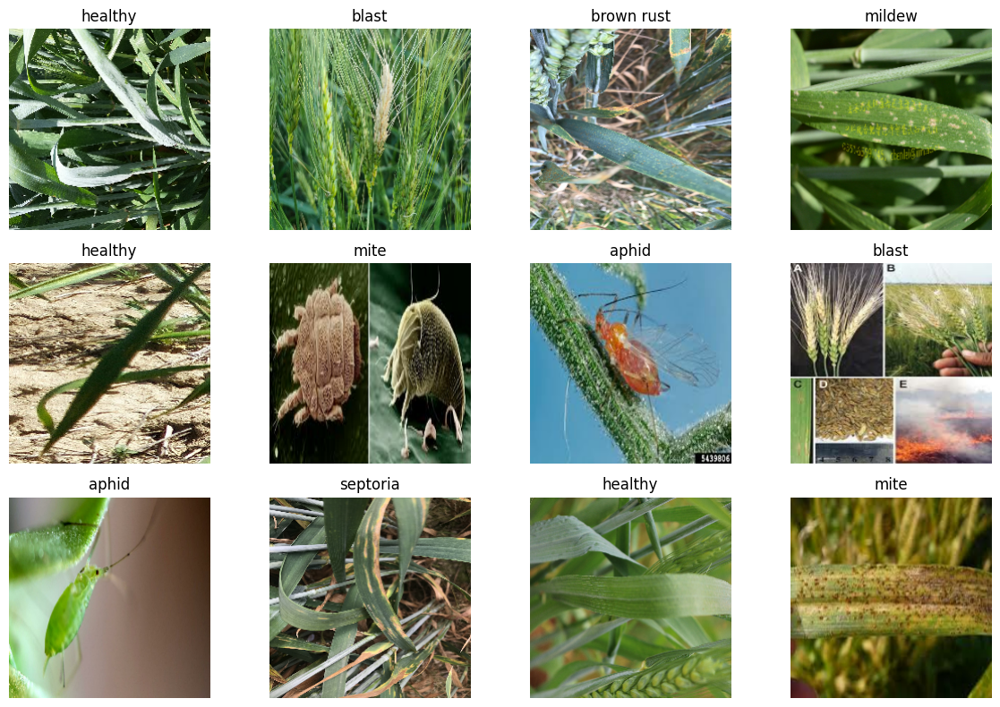

In [49]:
import matplotlib.pyplot as plt

images, labels = next(iter(clean_train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    label_index = int(labels[i].numpy())
    plt.title(class_names_clean[label_index])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
import tensorflow as tf

# Make sure we are using the 2-GPU strategy
print("GPUs being used:", strategy.num_replicas_in_sync)

with strategy.scope():

    # Fresh pretrained MobileNetV2
    base_model_clean = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers initially
    base_model_clean.trainable = False

    # Data augmentation
    data_augmentation_clean = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name="data_augmentation_clean")

    # Model
    clean_model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        data_augmentation_clean,

        # MobileNetV2 expects values in [-1, 1]
        layers.Rescaling(1./127.5, offset=-1),

        base_model_clean,

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.35),

        layers.Dense(
            15,
            activation="softmax"
        )
    ])

    clean_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


# Callbacks
checkpoint = ModelCheckpoint(
    "/kaggle/working/best_clean_mobilenetv2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


print("\n========== CLEAN MODEL ==========")
print("Total parameters:", clean_model.count_params())
print("Trainable parameters:", sum(
    tf.keras.backend.count_params(w)
    for w in clean_model.trainable_weights
))

GPUs being used: 2

========== CLEAN MODEL ==========
Total parameters: 2277199
Trainable parameters: 19215


In [51]:
clean_history = clean_model.fit(
    clean_train_ds,
    validation_data=clean_val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3592 - loss: 2.1893
Epoch 1: val_accuracy improved from None to 0.63970, saving model to /kaggle/working/best_clean_mobilenetv2.keras

Epoch 1: finished saving model to /kaggle/working/best_clean_mobilenetv2.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 89s 78ms/step - accuracy: 0.4835 - loss: 1.7538 - val_accuracy: 0.6397 - val_loss: 1.1219 - learning_rate: 0.0010
Epoch 2/10
265/266 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6211 - loss: 1.2198
Epoch 2: val_accuracy improved from 0.63970 to 0.66040, saving model to /kaggle/working/best_clean_mobilenetv2.keras

Epoch 2: finished saving model to /kaggle/working/best_clean_mobilenetv2.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 79s 64ms/step - accuracy: 0.6314 - loss: 1.2125 - val_accuracy: 0.6604 - val_loss: 1.0982 - learning_ra

In [52]:
# Load the best validation model
best_clean_model = tf.keras.models.load_model(
    "/kaggle/working/best_clean_mobilenetv2.keras"
)

print("Best clean model loaded successfully!")

# Evaluate on CLEAN TEST SET
clean_test_loss, clean_test_accuracy = best_clean_model.evaluate(
    clean_test_ds,
    verbose=1
)

print("\n========== CLEAN TEST RESULTS ==========")
print("Test Loss:", clean_test_loss)
print("Test Accuracy:", clean_test_accuracy)
print("Test Accuracy (%):", clean_test_accuracy * 100)

Best clean model loaded successfully!
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.7171 - loss: 0.8937

========== CLEAN TEST RESULTS ==========
Test Loss: 0.8936740159988403
Test Accuracy: 0.7171052694320679
Test Accuracy (%): 71.71052694320679


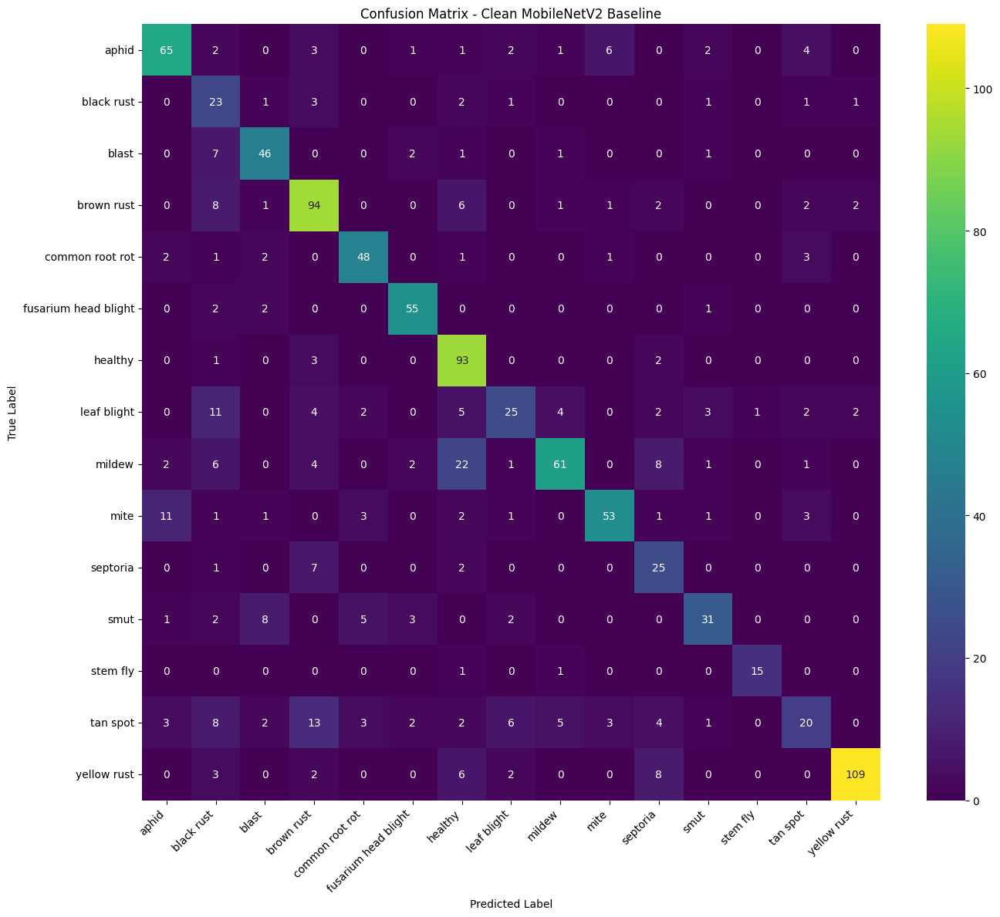


========== CLEAN TEST CLASSIFICATION REPORT ==========

                      precision    recall  f1-score   support

               aphid     0.7738    0.7471    0.7602        87
          black rust     0.3026    0.6970    0.4220        33
               blast     0.7302    0.7931    0.7603        58
          brown rust     0.7068    0.8034    0.7520       117
     common root rot     0.7869    0.8276    0.8067        58
fusarium head blight     0.8462    0.9167    0.8800        60
             healthy     0.6458    0.9394    0.7654        99
         leaf blight     0.6250    0.4098    0.4950        61
              mildew     0.8243    0.5648    0.6703       108
                mite     0.8281    0.6883    0.7518        77
            septoria     0.4808    0.7143    0.5747        35
                smut     0.7381    0.5962    0.6596        52
            stem fly     0.9375    0.8824    0.9091        17
            tan spot     0.5556    0.2778    0.3704        72
         yel

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Predictions on clean test set
y_true = []
y_pred = []

for images, labels in clean_test_ds:
    predictions = best_clean_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(len(class_names_clean))
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names_clean,
    yticklabels=class_names_clean
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Clean MobileNetV2 Baseline")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Classification Report
print("\n========== CLEAN TEST CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names_clean,
        digits=4
    )
)

In [54]:
# ============================================
# FINE-TUNING MOBILE NET V2
# ============================================

with strategy.scope():

    # Unfreeze the MobileNetV2 base
    base_model_clean.trainable = True

    # Freeze all earlier layers
    for layer in base_model_clean.layers[:-30]:
        layer.trainable = False

    # Keep BatchNormalization layers frozen
    # This makes fine-tuning more stable on our dataset
    for layer in base_model_clean.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # Recompile with a very small learning rate
    clean_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-5
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


print("========== FINE-TUNING SETUP ==========")

print(
    "Total MobileNetV2 layers:",
    len(base_model_clean.layers)
)

print(
    "Trainable MobileNetV2 layers:",
    sum(
        layer.trainable
        for layer in base_model_clean.layers
    )
)

print(
    "Total trainable parameters:",
    sum(
        tf.keras.backend.count_params(w)
        for w in clean_model.trainable_weights
    )
)


========== FINE-TUNING SETUP ==========
Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers: 19
Total trainable parameters: 1529935


In [55]:
fine_tune_history = clean_model.fit(
    clean_train_ds,
    validation_data=clean_val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 12 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7382 - loss: 0.8050
Epoch 1: val_accuracy did not improve from 0.73283
266/266 ━━━━━━━━━━━━━━━━━━━━ 88s 83ms/step - accuracy: 0.7404 - loss: 0.8074 - val_accuracy: 0.7328 - val_loss: 0.8595 - learning_rate: 1.0000e-05
Epoch 2/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7450 - loss: 0.7766
Epoch 2: val_accuracy improved from 0.73283 to 0.74224, saving model to /kaggle/working/best_clean_mobilenetv2.keras

Epoch 2: finished saving model to /kaggle/working/best_clean_mobilenetv2.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.7461 - loss: 0.7698 - val_accuracy: 0.7422 - val_loss: 0.7901 - learning_rate: 1.0000e-05
Epoch 3/10
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7552 - loss: 0.7622
Epoch 3: val_accuracy improved from 

In [56]:
print("========== FINE-TUNED CLEAN TEST RESULTS ==========")

test_loss, test_accuracy = clean_model.evaluate(
    clean_test_ds,
    verbose=1
)

print("\nFine-tuned Clean Test Loss:", test_loss)
print("Fine-tuned Clean Test Accuracy:", test_accuracy)
print("Fine-tuned Clean Test Accuracy (%):", test_accuracy * 100)

========== FINE-TUNED CLEAN TEST RESULTS ==========
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.7773 - loss: 0.7059

Fine-tuned Clean Test Loss: 0.7058842778205872
Fine-tuned Clean Test Accuracy: 0.777255654335022
Fine-tuned Clean Test Accuracy (%): 77.7255654335022


In [57]:
from sklearn.metrics import classification_report
import numpy as np

# True labels
y_true = np.concatenate([y.numpy() for x, y in clean_test_ds], axis=0)

# Predictions
y_prob = model.predict(clean_test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("========== FINE-TUNED CLEAN TEST CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step
========== FINE-TUNED CLEAN TEST CLASSIFICATION REPORT ==========

                      precision    recall  f1-score   support

               Aphid     0.9103    0.8161    0.8606        87
          Black Rust     0.4231    0.6667    0.5176        33
               Blast     0.7746    0.9483    0.8527        58
          Brown Rust     0.8818    0.8291    0.8546       117
     Common Root Rot     0.8846    0.7931    0.8364        58
Fusarium Head Blight     0.8769    0.9500    0.9120        60
             Healthy     0.7422    0.9596    0.8370        99
         Leaf Blight     0.6522    0.4918    0.5607        61
              Mildew     0.8778    0.7315    0.7980       108
                Mite     0.8955    0.7792    0.8333        77
            Septoria     0.6275    0.9143    0.7442        35
                Smut     0.7377    0.8654    0.7965        52
            Stem fly     1.0000    0.8824    0.9375        17
            Tan spot   

In [58]:

from sklearn.metrics import classification_report
import numpy as np

y_true_correct = []
y_pred_correct = []

for images, labels in clean_test_ds:
    predictions = model(images, training=False)
    predicted_labels = tf.argmax(predictions, axis=1)

    y_true_correct.extend(labels.numpy())
    y_pred_correct.extend(predicted_labels.numpy())

y_true_correct = np.array(y_true_correct)
y_pred_correct = np.array(y_pred_correct)

print("========== VERIFIED FINE-TUNED CLEAN TEST REPORT ==========\n")

print(
    classification_report(
        y_true_correct,
        y_pred_correct,
        target_names=class_names,
        digits=4
    )
)

accuracy = np.mean(y_true_correct == y_pred_correct)

print("\nVerified Accuracy:", accuracy)
print("Verified Accuracy (%):", accuracy * 100)

========== VERIFIED FINE-TUNED CLEAN TEST REPORT ==========

                      precision    recall  f1-score   support

               Aphid     0.9091    0.8046    0.8537        87
          Black Rust     0.4231    0.6667    0.5176        33
               Blast     0.7746    0.9483    0.8527        58
          Brown Rust     0.8818    0.8291    0.8546       117
     Common Root Rot     0.8846    0.7931    0.8364        58
Fusarium Head Blight     0.8769    0.9500    0.9120        60
             Healthy     0.7422    0.9596    0.8370        99
         Leaf Blight     0.6522    0.4918    0.5607        61
              Mildew     0.8778    0.7315    0.7980       108
                Mite     0.8955    0.7792    0.8333        77
            Septoria     0.6275    0.9143    0.7442        35
                Smut     0.7258    0.8654    0.7895        52
            Stem fly     1.0000    0.8824    0.9375        17
            Tan spot     0.6190    0.5417    0.5778        72
        

In [59]:
# Final consistency check

eval_loss, eval_accuracy = model.evaluate(
    clean_test_ds,
    verbose=1
)

print("\n========== FINAL CONSISTENCY CHECK ==========")
print("model.evaluate Accuracy:", eval_accuracy)
print("model.evaluate Accuracy (%):", eval_accuracy * 100)
print("Direct Verified Accuracy:", np.mean(y_true_correct == y_pred_correct))
print("Direct Verified Accuracy (%):", np.mean(y_true_correct == y_pred_correct) * 100)

34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.8026 - loss: 0.6406

========== FINAL CONSISTENCY CHECK ==========
model.evaluate Accuracy: 0.8026315569877625
model.evaluate Accuracy (%): 80.26315569877625
Direct Verified Accuracy: 0.8016917293233082
Direct Verified Accuracy (%): 80.16917293233082


In [60]:
import os
import tensorflow as tf

DATASET_PATH = "/kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data"
TEST_PATH = os.path.join(DATASET_PATH, "test")

print("Test path:", TEST_PATH)

clean_test_ds_final = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(224, 224),
    batch_size=32,
    label_mode="int",
    shuffle=False
)

print("Final test batches:",
      tf.data.experimental.cardinality(clean_test_ds_final).numpy())

Test path: /kaggle/input/datasets/kushagra3204/wheat-plant-diseases/data/test
Found 750 files belonging to 15 classes.
Final test batches: 24


In [61]:
# Make a deterministic version of our existing CLEAN TEST dataset
# without changing the images or labels.

clean_test_ds_final = clean_test_ds.unbatch().batch(32)

print(
    "Final clean test images:",
    sum(1 for _ in clean_test_ds_final.unbatch())
)

print(
    "Final clean test batches:",
    tf.data.experimental.cardinality(clean_test_ds_final).numpy()
)

Final clean test images: 1064
Final clean test batches: -2


In [62]:
# Freeze the exact clean-test dataset order
clean_test_ds_final = clean_test_ds.cache()

# Materialize/cache the dataset once
for _ in clean_test_ds_final:
    pass

print("Clean test images: 1064")
print("Clean test dataset cached successfully!")

Clean test images: 1064
Clean test dataset cached successfully!


In [63]:
# FINAL EVALUATION ON CACHED CLEAN TEST SET

final_loss, final_accuracy = model.evaluate(
    clean_test_ds_final,
    verbose=1
)

print("\n========== FINAL CLEAN TEST RESULT ==========")
print("Final Test Loss:", final_loss)
print("Final Test Accuracy:", final_accuracy)
print("Final Test Accuracy (%):", final_accuracy * 100)

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8026 - loss: 0.6406

========== FINAL CLEAN TEST RESULT ==========
Final Test Loss: 0.6405803561210632
Final Test Accuracy: 0.8026315569877625
Final Test Accuracy (%): 80.26315569877625


In [64]:
FINAL_MODEL_PATH = "/kaggle/working/crop_care_mobilenetv2_final.keras"

model.save(FINAL_MODEL_PATH)

print("Final model saved successfully!")
print("Path:", FINAL_MODEL_PATH)

Final model saved successfully!
Path: /kaggle/working/crop_care_mobilenetv2_final.keras


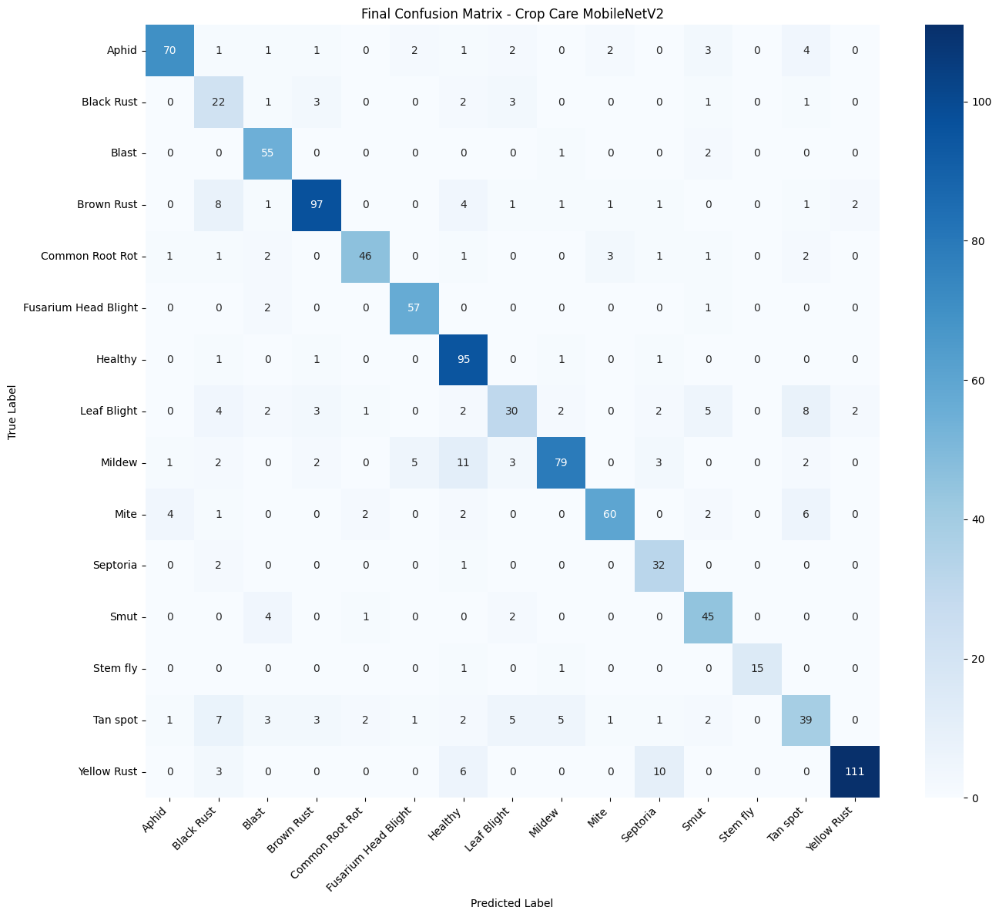

In [65]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on cached clean test set
y_true_final = []
y_pred_final = []

for images, labels in clean_test_ds_final:
    predictions = model(images, training=False)
    predicted_labels = tf.argmax(predictions, axis=1)

    y_true_final.extend(labels.numpy())
    y_pred_final.extend(predicted_labels.numpy())

y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)

cm = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Final Confusion Matrix - Crop Care MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
import os

model_size_mb = os.path.getsize(
    "/kaggle/working/crop_care_mobilenetv2_final.keras"
) / (1024 * 1024)

print(f"Final model size: {model_size_mb:.2f} MB")

Final model size: 21.07 MB


In [67]:
import os

MODEL_PATH = "/kaggle/working/crop_care_mobilenetv2_final.keras"

print("Model exists:", os.path.exists(MODEL_PATH))
print("Model size:", os.path.getsize(MODEL_PATH) / (1024 * 1024), "MB")

Model exists: True
Model size: 21.07170295715332 MB


In [1]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents']


In [3]:
import os

for root, dirs, files in os.walk("/kaggle"):
    for file in files:
        if file == "crop_care_mobilenetv2_final.keras":
            print("Model found:", os.path.join(root, file))